In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

# データの読み込み
df = pd.read_csv("../data/preprocessed_data.csv", index_col=0, parse_dates=True)

# 特徴量（X）と目的変数（y）の分離
X = df.drop(columns=["OT"])  # すべての特徴量
y = df["OT"]  # 予測対象（オイル温度）

# データを訓練データ（80%）とテストデータ（20%）に分割（shuffle=False）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

# **インデックスを元に戻す**
X_train = pd.DataFrame(X_train, index=X.index[:len(X_train)], columns=X.columns)
X_test = pd.DataFrame(X_test, index=X.index[len(X_train):], columns=X.columns)
y_train = pd.Series(y_train, index=y.index[:len(y_train)], name="OT")
y_test = pd.Series(y_test, index=y.index[len(y_train):], name="OT")

# **確認**
print("==== 🟢 `X_train` のインデックス範囲 ====")
print(X_train.index.min(), "→", X_train.index.max())

print("==== 🔵 `X_test` のインデックス範囲 ====")
print(X_test.index.min(), "→", X_test.index.max())


==== 🟢 `X_train` のインデックス範囲 ====
2016-07-01 00:00:00 → 2018-02-01 15:00:00
==== 🔵 `X_test` のインデックス範囲 ====
2018-02-01 16:00:00 → 2018-06-26 19:00:00


NaN の発生理由として考えられるのは以下の3つ：

ラグ特徴量 (OT_lag1, OT_lag2 など) に NaN がある
→ データの最初の数行（時系列の過去データがない部分）に NaN ができる。
移動平均 (OT_roll_mean_3, OT_roll_mean_6) に NaN がある
→ 初期の数行は計算できないため NaN が出る。
他の欠損値 (HUFL, HULL など)
→ もし他の変数に NaN があるなら、その処理も考慮する必要がある。


NaNを前後の値で埋める

In [21]:
# `X_train` と `y_train` の `NaN` を直前 & 直後の値で埋める
X_train.fillna(method="ffill", inplace=True)
X_train.fillna(method="bfill", inplace=True)
X_test.fillna(method="ffill", inplace=True)
X_test.fillna(method="bfill", inplace=True)
y_train.fillna(method="ffill", inplace=True)
y_train.fillna(method="bfill", inplace=True)
y_test.fillna(method="ffill", inplace=True)
y_test.fillna(method="bfill", inplace=True)

# 念のため、まだ `NaN` が残っていないか確認
print("X_train NaN:", X_train.isnull().sum().sum())  # 0 なら OK
print("X_test NaN:", X_test.isnull().sum().sum())    # 0 なら OK
print("y_train NaN:", y_train.isnull().sum())        # 0 なら OK
print("y_test NaN:", y_test.isnull().sum())          # 0 なら OK



X_train NaN: 0
X_test NaN: 0
y_train NaN: 0
y_test NaN: 0


C:\Users\mutow\AppData\Local\Temp\ipykernel_9236\1028246558.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train.fillna(method="ffill", inplace=True)
C:\Users\mutow\AppData\Local\Temp\ipykernel_9236\1028246558.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train.fillna(method="bfill", inplace=True)
C:\Users\mutow\AppData\Local\Temp\ipykernel_9236\1028246558.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test.fillna(method="ffill", inplace=True)
C:\Users\mutow\AppData\Local\Temp\ipykernel_9236\1028246558.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test.fillna(method="bfill", inplace=True)
C:\Use

線形回帰モデルをトレーニング

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# モデルの作成 & 学習
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 予測
y_pred_lr = lr_model.predict(X_test)

# RMSE の計算
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f"線形回帰の RMSE: {rmse_lr}")


線形回帰の RMSE: 0.00010541239612258883


超低い RMSE（ほぼゼロ） なので、何かしら異常に高い精度が出てしまっている

In [23]:
print(X_train.columns)  # すべての特徴量を確認


Index(['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'hour', 'is_peak_hour',
       'is_night', 'dayofweek', 'month', 'OT_lag1', 'OT_lag2', 'OT_lag3',
       'OT_roll_mean_3', 'OT_roll_mean_6', 'OT_roll_mean_12', 'is_summer',
       'is_winter', 'monthly_temp_anomaly'],
      dtype='object')


c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK

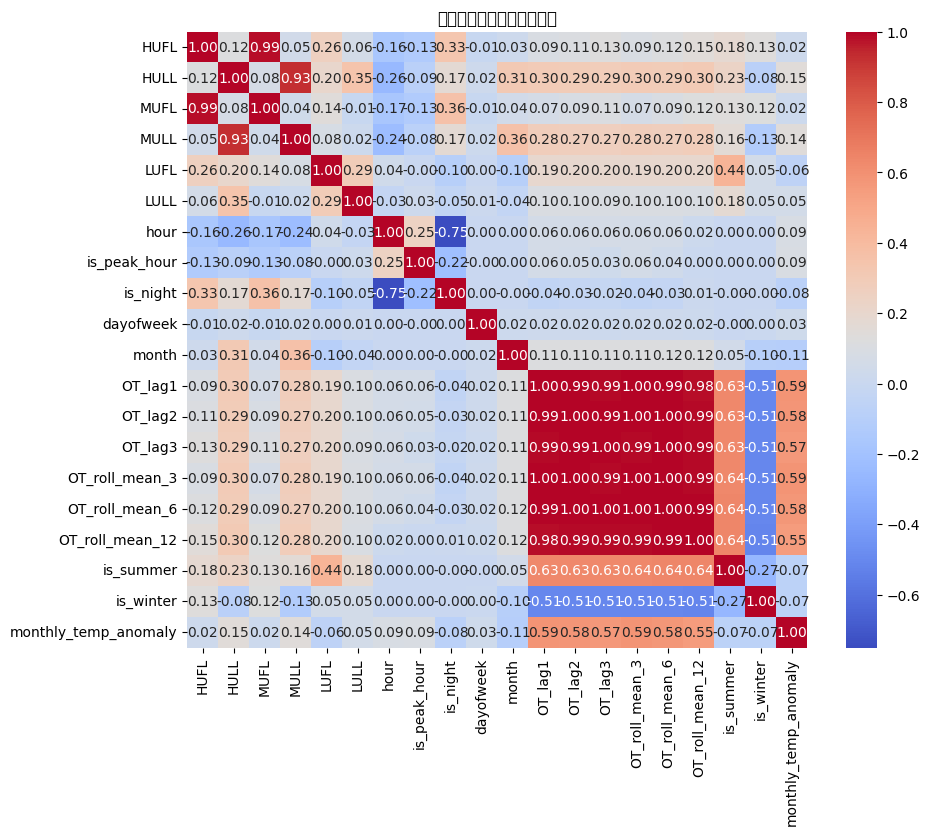

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("特徴量の相関マトリックス")
plt.show()


同じ値を含んでいる可能性があるので、「1.00 に近いもの」だけ削除する

In [25]:
print(f"🔍 削除前の X_train shape: {X_train.shape}")
print(f"🔍 削除前の X_test shape: {X_test.shape}")


🔍 削除前の X_train shape: (13936, 20)
🔍 削除前の X_test shape: (3484, 20)


In [26]:
# 削除する特徴量リスト
high_corr_features = ["MUFL", "MULL", "OT_lag1", "OT_lag2", "OT_lag3", "OT_roll_mean_3", "OT_roll_mean_6"]

# 訓練データ・テストデータから削除
X_train = X_train.drop(columns=high_corr_features, errors="ignore")
X_test = X_test.drop(columns=high_corr_features, errors="ignore")

# 削除後の確認
print("✅ 削除後の X_train のカラム:", X_train.columns)


✅ 削除後の X_train のカラム: Index(['HUFL', 'HULL', 'LUFL', 'LULL', 'hour', 'is_peak_hour', 'is_night',
       'dayofweek', 'month', 'OT_roll_mean_12', 'is_summer', 'is_winter',
       'monthly_temp_anomaly'],
      dtype='object')


削除後の相関マトリクスを再確認

c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30456 (\N{CJK

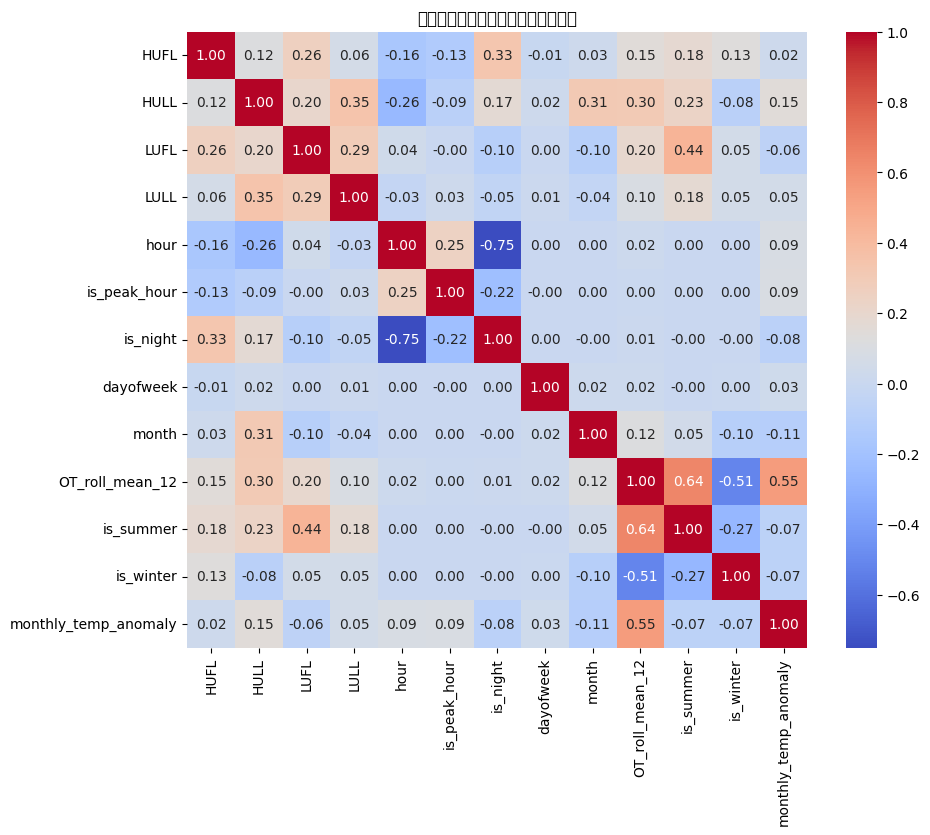

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("特徴量の相関マトリクス（削除後）")
plt.show()


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 線形回帰モデルを作成 & 学習
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 予測
y_pred_lr = lr_model.predict(X_test)

# RMSE 計算
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"✅ 線形回帰の RMSE: {rmse_lr:.4f}")


✅ 線形回帰の RMSE: 0.0214


データリーク（未来のデータが含まれているか）をチェック

In [29]:
print(X_train.head())  # 未来のデータが入っていないか？
print(y_test.head())  # 予測対象のデータと比較


                         HUFL      HULL      LUFL      LULL  hour  \
date                                                                
2016-07-01 00:00:00  0.615599  0.454943  0.556576  0.613765     0   
2016-07-01 01:00:00  0.612708  0.459449  0.550279  0.620783     1   
2016-07-01 02:00:00  0.601143  0.436920  0.512595  0.586144     2   
2016-07-01 03:00:00  0.599698  0.450437  0.515693  0.599955     3   
2016-07-01 04:00:00  0.605480  0.450437  0.521990  0.599955     4   

                     is_peak_hour  is_night  dayofweek  month  \
date                                                            
2016-07-01 00:00:00             0         1          4      7   
2016-07-01 01:00:00             0         1          4      7   
2016-07-01 02:00:00             0         1          4      7   
2016-07-01 03:00:00             0         1          4      7   
2016-07-01 04:00:00             0         1          4      7   

                     OT_roll_mean_12  is_summer  is_winter  

データリークはされていない

過学習をチェック

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# モデルの作成と学習
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 訓練データとテストデータの予測
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# 訓練データの RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))

# テストデータの RMSE
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print(f"📊 訓練データの RMSE: {rmse_train:.4f}")
print(f"📊 テストデータの RMSE: {rmse_test:.4f}")


📊 訓練データの RMSE: 0.0256
📊 テストデータの RMSE: 0.0214


訓練データとテストデータの RMSE に大きな差がないので、過学習の可能性が低い！

ランダムフォレストで実施

In [31]:
from sklearn.ensemble import RandomForestRegressor

# ランダムフォレストの学習
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 予測
y_pred_rf = rf_model.predict(X_test)

# RMSE 計算
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"✅ ランダムフォレストの RMSE: {rmse_rf:.4f}")


✅ ランダムフォレストの RMSE: 0.0194


In [32]:
# 削除後の shape を確認
print(f"✅ 削除後の X_train shape: {X_train.shape}")
print(f"✅ 削除後の X_test shape: {X_test.shape}")

✅ 削除後の X_train shape: (13936, 13)
✅ 削除後の X_test shape: (3484, 13)


In [33]:
removed_features = len(high_corr_features)
print(f"📉 削除した特徴量の数: {removed_features}")
print(f"📊 特徴量の変化: {X_train.shape[1] + removed_features} → {X_train.shape[1]}")


📉 削除した特徴量の数: 7
📊 特徴量の変化: 20 → 13


RMSE / 標準偏差を計算（低すぎるか確認）

データ量は減らずに特徴量のみ減っているのでOK！

In [34]:
import numpy as np

# **訓練データの標準偏差を計算**
std_ot = np.std(y_train)

print(f"📊 訓練データ（OT）の標準偏差: {std_ot:.4f}")


📊 訓練データ（OT）の標準偏差: 0.1774


In [35]:
# RMSE / 標準偏差を計算
rmse_ratio_lr = (0.0214 / 0.1774) * 100
rmse_ratio_rf = (0.0194 / 0.1774) * 100

print(f"✅ 線形回帰 RMSE / 標準偏差: {rmse_ratio_lr:.2f}%")
print(f"✅ ランダムフォレスト RMSE / 標準偏差: {rmse_ratio_rf:.2f}%")


✅ 線形回帰 RMSE / 標準偏差: 12.06%
✅ ランダムフォレスト RMSE / 標準偏差: 10.94%


どちらも10%前後
→適切な範囲

最終的なモデルの評価

線形回帰 RMSE / 標準偏差: 12.06%
ランダムフォレスト RMSE / 標準偏差: 10.94%

線形回帰の RMSE: 0.0214
ランダムフォレストの RMSE: 0.0194

ランダムフォレストの方が正確で適している。

作成したモデルを保存

In [36]:
# 削除前のデータをコピー
df_after = X_train.copy()

# 削除後のデータを保存
df_after.to_csv("../data/feature_correlation_after.csv", index=True)

print("✅ データの保存が完了しました！")

✅ データの保存が完了しました！
